# Sentiment Analysis

*Sentiment analysis* is the task of evaluating whether a given passage of text is primarily "positive" or "negative." The meanings of these terms can change in context. For example, a "positive" product review would indicate that the customer likes the product, whereas a "positive" tweet might just indicate that the user is happy that day. 

In this lecture, we'll discuss how familiar machine learning tools can allow us to perform sentiment analysis on unstructured text. 

Our data set for this task comes from the `nltk` package again. It's a set of movie reviews. 

In [1]:
import numpy as np
import pandas as pd
import nltk

nltk.download('movie_reviews')
from nltk.corpus import movie_reviews



# simple imports

# import numpy as np, import pandas as pd, import nltk

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/muchasmesas/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


The `movie_reviews` object allows us to read in the data. 

In [2]:
movie_reviews

<CategorizedPlaintextCorpusReader in '/Users/muchasmesas/nltk_data/corpora/movie_reviews'>

For today, the two most important methods of this object are `fileids()` and `raw()`. The first method will allow us to locate the files on disk in which the movie reviews are contained, and the second method will allow us to then obtain the full text of the reviews from the file path. 

Let's first look at the fileids. 

In [3]:
f = movie_reviews.fileids()[0]
f

'neg/cv000_29416.txt'

Each review is contained in its own file, in one of two folders. The `neg` folder contains negative reviews, while the `pos` folder contains positive reviews. 

Once we have picked fixed a file path, we can then use the `raw()` method to extract the raw text of the movie review. 

In [4]:
movie_reviews.raw(f)

'plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience membe

Take a moment to think: how can we read in the complete data set? 

<br> 
<br> 

A `for`-loop would be one way. In this approach, we would create an empty list to hold the review texts, iterate over the list of file paths, and populate the list for texts as we go. For example: 

In [5]:
raw_texts = []      # going to fill this to hold the reviews

# iterate over the file paths then get then using .raw

for p in movie_reviews.fileids():
    raw_texts.append(movie_reviews.raw(p))

print(type(raw_texts),len(raw_texts))

<class 'list'> 2000


This does work, but it requires three lines and still leaves us with the task of bringing the texts into a format (like a data frame) that we know how to work with. 

Using the `apply` method from `pandas` gives us a much more efficient way: 

In [6]:
# create a data frame whose only column contains the fileids
df = pd.DataFrame({'fileid':movie_reviews.fileids()})


# create a new column by applying the movie_reviews.raw()
# method to each entry of df['fileid']
df['raw_text'] = df['fileid'].apply(movie_reviews.raw)


In [7]:
df

,fileid,raw_text
0,neg/cv000_29416.txt,"plot : two teen couples go to a church party ,..."
1,neg/cv001_19502.txt,the happy bastard's quick movie review \ndamn ...
2,neg/cv002_17424.txt,it is movies like these that make a jaded movi...
3,neg/cv003_12683.txt,""" quest for camelot "" is warner bros . ' firs..."
4,neg/cv004_12641.txt,synopsis : a mentally unstable man undergoing ...
...,...,...
1995,pos/cv995_21821.txt,wow ! what a movie . \nit's everything a movie...
1996,pos/cv996_11592.txt,"richard gere can be a commanding actor , but h..."
1997,pos/cv997_5046.txt,"glory--starring matthew broderick , denzel was..."
1998,pos/cv998_14111.txt,steven spielberg's second epic film on world w...


We now have read in the data. Do we have what we need for sentiment analysis? 

Not quite yet, but we're close! In this lecture, we'll treat sentiment analysis as a form of *classification*: our aim is to build a machine learning model that we can use to predict whether a given text is positive or negative. For this approach, we are going to need both target and predictor variables. Fortunately, we know how to obtain both of these. 

In [8]:
# check whether the text came from the pos folder. 
df['is_good'] = df['fileid'].str.split('/').str.get(0) == 'pos'         # saw this before.. yes
df

,fileid,raw_text,is_good
0,neg/cv000_29416.txt,"plot : two teen couples go to a church party ,...",False
1,neg/cv001_19502.txt,the happy bastard's quick movie review \ndamn ...,False
2,neg/cv002_17424.txt,it is movies like these that make a jaded movi...,False
3,neg/cv003_12683.txt,""" quest for camelot "" is warner bros . ' firs...",False
4,neg/cv004_12641.txt,synopsis : a mentally unstable man undergoing ...,False
...,...,...,...
1995,pos/cv995_21821.txt,wow ! what a movie . \nit's everything a movie...,True
1996,pos/cv996_11592.txt,"richard gere can be a commanding actor , but h...",True
1997,pos/cv997_5046.txt,"glory--starring matthew broderick , denzel was...",True
1998,pos/cv998_14111.txt,steven spielberg's second epic film on world w...,True


We can use tools from before to create a term-document matrix. This time, we treat each movie review as a document. 

In [9]:
# term document matrix is splitting up the fucking words...

# step 1 import the module
from sklearn.feature_extraction.text import CountVectorizer

# step 2 initiailize 
vec = CountVectorizer(max_df=0.2, min_df=30, stop_words='english')

# step 3 transofmr the 'text' column
counts = vec.fit_transform(df['raw_text'])

# step 4 turn to df
counts_df = pd.DataFrame(counts.toarray(), columns=vec.get_feature_names_out())

### A closer look at the term-document matrix

It's worth slowing down on what `CountVectorizer` just did, since this is the step where the text actually becomes numbers.

The vectorizer builds a *vocabulary* — the list of words that appear across our reviews — and then represents each review as a row of counts: how many times each vocabulary word shows up in that review. This is the **bag-of-words** representation. The name is honest about its main limitation: it records *which* words appear and *how often*, but throws away the *order*. To the model, "this was not good, just bad" and "this was not bad, just good" look almost identical. Negation, sarcasm, and word order are exactly the things bag-of-words struggles with — worth keeping in mind when we look at where the model makes mistakes.

The three arguments we passed are all doing real work:

- `stop_words='english'` drops extremely common words like *the*, *is*, *and*. They appear everywhere and carry almost no sentiment signal, so we remove them.
- `min_df=30` keeps only words that appear in at least 30 reviews. Anything rarer is usually noise (typos, character names, one-off references) and mostly gives the model a chance to memorize individual reviews.
- `max_df=0.2` drops words that appear in more than 20% of reviews. A word that shows up in nearly every review (like *movie* or *film*) can't help us tell positive from negative.

Together, `min_df` and `max_df` keep words in a useful middle band: common enough to generalize, rare enough to discriminate. Let's see how many survived.

In [10]:
counts.shape

(2000, 3024)

In [11]:
# step 5, now concatenate
df = pd.concat((df,counts_df), axis=1)

In [12]:
df

,fileid,raw_text,is_good,000,10,100,11,12,13,15,...,writing,written,wrong,wrote,yeah,yes,york,younger,youth,zero
0,neg/cv000_29416.txt,"plot : two teen couples go to a church party ,...",False,0,10,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,neg/cv001_19502.txt,the happy bastard's quick movie review \ndamn ...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,neg/cv002_17424.txt,it is movies like these that make a jaded movi...,False,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
3,neg/cv003_12683.txt,""" quest for camelot "" is warner bros . ' firs...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,neg/cv004_12641.txt,synopsis : a mentally unstable man undergoing ...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,pos/cv995_21821.txt,wow ! what a movie . \nit's everything a movie...,True,0,1,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
1996,pos/cv996_11592.txt,"richard gere can be a commanding actor , but h...",True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,pos/cv997_5046.txt,"glory--starring matthew broderick , denzel was...",True,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1998,pos/cv998_14111.txt,steven spielberg's second epic film on world w...,True,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We have now successfully read in and prepared our data. 

---

## On to Sentiment Analysis

These steps should be pretty familiar. We are going to split our data into training and test sets, create a logistic classifier, and evaluate the logistic classifier on the 

In [14]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.4)  # seen this before

X_train = train.drop(['fileid','raw_text','is_good'], axis=1)   # dropping these cols
y_train = train['is_good']

X_test = test.drop(['fileid','raw_text','is_good'], axis=1)   # dropping these cols
y_test = test['is_good']

> **A subtlety worth flagging.** Notice that we ran `CountVectorizer` on the *full* data set (when we built `counts`) and only split into train and test *afterward*. That means the vocabulary — and the `min_df` / `max_df` thresholds — were chosen using the test reviews too. This is a mild form of *data leakage*: the test set isn't quite as "unseen" as we'd like. For a classroom example it barely moves the numbers, but in a real evaluation you'd fit the vectorizer on the training data only. We'll show the clean way to do this with a `Pipeline` at the very end.

### What is the logistic model actually doing?

For each review, the model takes the word counts $x_1, x_2, \dots, x_p$ and forms a weighted sum

$$ z = w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b. $$

It then squashes $z$ through the *logistic (sigmoid)* function to turn it into a probability that the review is positive:

$$ P(\text{positive}) = \frac{1}{1 + e^{-z}}. $$

The weights $w_j$ are what training learns. The useful way to read them: $w_j$ is the amount the **log-odds** of "positive" change when word $j$ appears one more time. A large positive $w_j$ pushes a review toward "positive"; a large negative $w_j$ pushes it toward "negative." That's exactly the interpretation we'll cash in at the end when we read off which words carry positive and negative sentiment — those word scores *are* the coefficients $w_j$.

In [15]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(X_train, y_train)
LR.score(X_train,y_train), LR.score(X_test,y_test)

(1.0, 0.80875)

In [16]:
from sklearn.model_selection import cross_val_score

cross_val_score(LR, X_train, y_train, cv=5).mean()

np.float64(0.7833333333333333)

Our model perfectly fits the training data, but based on CV it looks like our predictive accuracy might only be around 80%. This looks like overfitting, which makes sense -- overfitting is a very common problem when we have many predictor columns (lots of words) and not that many data observations. 

There are multiple ways to address this. In this lecture, let's use the regularization parameter `C`, which controls model complexity in logistic regression. While one could be more systematic about this, here's a simple little loop: 

In [17]:
for c in np.linspace(0.005, 0.05, 10):
    print(str(np.round(c,4)), end=': ')
    LR = LogisticRegression(C=c)
    cv_score = cross_val_score(LR, X_train, y_train, cv=5).mean()
    print(np.round(cv_score,3))

0.005: 0.784
0.01: 0.785
0.015: 0.788
0.02: 0.786
0.025: 0.789
0.03: 0.787
0.035: 0.789
0.04: 0.788
0.045: 0.788
0.05: 0.789


Looks like we can improve our estimated accuracy using C = 0.02 or so. Let's do that and evaluate on the test set. 

In [19]:
LR = LogisticRegression(C=0.045)
LR.fit(X_train, y_train)
print(LR.score(X_train, y_train), LR.score(X_test, y_test))

0.9983333333333333 0.8225


### Looking past the single accuracy number

That ~80% is a useful headline, but accuracy alone hides a lot — it doesn't tell us *what kind* of mistakes the model makes. A *confusion matrix* breaks the predictions down into the four cases (correct positives, correct negatives, and the two kinds of error):

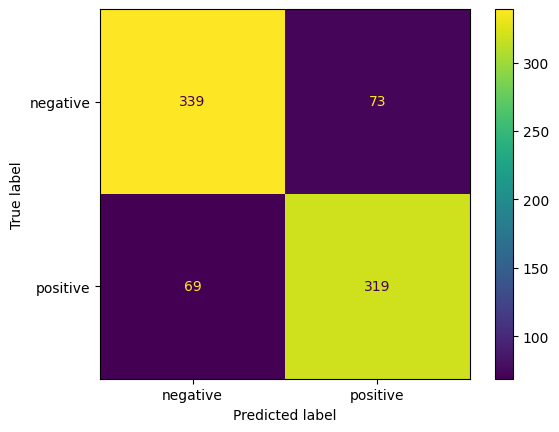

In [20]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = LR.predict(X_test)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels = ['negative','positive']).plot()
plt.show()

`classification_report` adds **precision** (of the reviews we *called* positive, how many really were) and **recall** (of the truly positive reviews, how many we *caught*). Here the two classes are balanced — 1000 positive and 1000 negative reviews — so accuracy is a fair summary. But the moment the classes are imbalanced, accuracy becomes misleading. Think ahead to the spam example: if 95% of email is legitimate, a model that blindly labels *everything* "not spam" already scores 95% accuracy while catching zero spam. That's exactly where precision and recall earn their keep.

So, our simple logistic model is able to correctly identify vs. negative movie reviews about 80% of the time. Not bad! 

However, we're not done yet. 

One of the primary purposes of sentiment analysis is to determine which words carry positive or negative associations. It is common to assign scores to each word that govern how positive or negative they are. We can do this using the coefficients of the logistic model. First, let's make a data frame of the words and their scores. 

In [21]:
result_df = pd.DataFrame({'coef':LR.coef_[0], 'word':X_train.columns})

Each row of `result_df` pairs a word with its coefficient $w_j$ from the fitted model. Reading back from the logistic model above, this number is the word's *sentiment score*: how much seeing that word shifts a review's log-odds toward "positive." Words with the most negative coefficients drag a review toward "negative"; words with the most positive coefficients push it toward "positive." So sorting this data frame by `coef` is literally asking the model which words it learned to associate with each sentiment.

Now let's sort the data frame to see the most negative words according to the model. 

In [22]:
result_df.sort_values('coef',ascending=True).head(10)

,coef,word
3002,-0.344921,worst
2626,-0.342704,supposed
2587,-0.302144,stupid
308,-0.279227,boring
2814,-0.276022,tv
2837,-0.260339,unfortunately
453,-0.248070,cheap
2139,-0.246661,reason
1993,-0.237653,poor
217,-0.231762,awful


That makes sense! What about the most positive words? 

In [23]:
result_df.sort_values('coef', ascending=False).head(10)

,coef,word
925,0.269713,excellent
1696,0.267632,memorable
903,0.251298,especially
1112,0.225885,frank
2801,0.222323,true
250,0.221879,beautiful
1938,0.214659,performances
2982,0.201000,won
2383,0.198784,shot
1282,0.198705,hilarious


This also looks pretty logical. We can conclude that our model has had some success in learning which words have positive and negative meanings. 

Of course, the story isn't over: there are many different models that can be used for sentiment analysis, some of which highlight different features. 

Finally, the combination of term-document extraction with classification models isn't just for sentiment analysis! Essentially the same pipeline can work to produce a functioning spam classifier, in which a "negative" set of text is spam and a "positive" set of text is a legitimate email. 

## Going further

The pipeline we built — turn text into counts, fit a classifier, read the coefficients — is a complete, working sentiment analyzer. A few natural extensions are worth knowing about.

### TF–IDF instead of raw counts

Raw counts treat every occurrence of a word as equally informative, which over-weights words that are simply frequent. **TF–IDF** (term frequency–inverse document frequency) rescales each count by how rare the word is across the whole corpus, so distinctive words count for more and ubiquitous ones count for less. In scikit-learn it's a one-line swap — `TfidfVectorizer` is a drop-in replacement for `CountVectorizer`:

In [24]:

# (both still vectorize on all data -- the Pipeline below fixes that properly)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(min_df = 30, max_df=0.2, stop_words='english')

X_tfidf = tfidf_vec.fit_transform(df['raw_text'])
y = df['is_good']

LR=LogisticRegression(C=0.045)
print(cross_val_score(LR,X_tfidf, y, cv=5).mean())
# (both still vectorize on all data -- the Pipeline below fixes that properly)


0.807


### Fitting the vectorizer the right way, with a `Pipeline`

Earlier we flagged that fitting the vectorizer on the full data set before splitting leaks a little test information into our vocabulary. The clean fix is a `Pipeline`, which chains the vectorizer and the classifier into a single object. When we cross-validate the pipeline, scikit-learn re-fits the vectorizer *inside each fold* using only that fold's training data — so the held-out reviews never touch the vocabulary.

In [25]:
from sklearn.pipeline import Pipeline

text_train, text_test, label_train, label_test = train_test_split(
    df['raw_text'],
    df['is_good'],
    test_size =0.4,
    random_state=123,
    stratify=df['is_good']
)
# we feed in raw text and labels directly -- the pipeline handles vectorizing
pipe = Pipeline([
    ('vectorizer', TfidfVectorizer(min_df=30, max_df=0.2, stop_words='english')),
    ('classifier', LogisticRegression(C=0.045))
])

print(
    'leakage-free CV accuracy:',
    cross_val_score(pipe, df['raw_text'], df['is_good'],cv=5).mean()
)


leakage-free CV accuracy: 0.8019999999999999


### Where sentiment analysis goes from here

Our model only knows individual words. The most direct upgrade is to let `CountVectorizer` count short phrases too — `ngram_range=(1, 2)` adds two-word pairs like *not good*, which recovers some of the word-order information bag-of-words throws away. Beyond that, modern sentiment analysis usually replaces counts with learned *word embeddings*, and uses neural models — and these days, large pretrained language models — that represent meaning in context rather than as isolated words. But the core idea you built today, turning text into features and learning weights that separate the classes, is still very much at the heart of it.